In [1]:
import numpy as np
import pandas as pd

from src.datasets.sms_spam_collection import _load, _split, _preprocess

In [2]:
df = _load()
train_df, val_df, test_df = _split(df, val_size=0.2, test_size=0.1, random_state=42)

print(f'full: {df.shape}')
print(f'train: {train_df.shape}, val: {val_df.shape}, test: {test_df.shape}')
display(train_df.head())

full: (5572, 2)
train: (3899, 2), val: (1115, 2), test: (558, 2)


,label,text
0,ham,I'm also came to room.
1,ham,So check your errors and if you had difficulti...
2,ham,S:)but he had some luck.2 catches put down:)
3,ham,"I'm taking derek &amp; taylor to walmart, if I..."
4,spam,4mths half price Orange line rental & latest c...


In [3]:
data = _preprocess(train_df, val_df, test_df, mode='tfidf', max_features=15000)

X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val:  ', X_val.shape, 'y_val:  ', y_val.shape)
print('X_test: ', X_test.shape, 'y_test: ', y_test.shape)

X_train: (3899, 10568) y_train: (3899,)
X_val:   (1115, 10568) y_val:   (1115,)
X_test:  (558, 10568) y_test:  (558,)


In [4]:
# Примитивная проверка дисбаланса классов
train_spam_rate = y_train.mean()
val_spam_rate = y_val.mean()
test_spam_rate = y_test.mean()

print(f'spam rate train: {train_spam_rate:.3f}')
print(f'spam rate val:   {val_spam_rate:.3f}')
print(f'spam rate test:  {test_spam_rate:.3f}')

spam rate train: 0.134
spam rate val:   0.134
spam rate test:  0.134


In [5]:
from src.model import (
    LogisticRegressionClassifier,
    MultinomialNBClassifier,
    BernoulliNBClassifier,
    SVCClassifier,
    RandomForestClassifierModel,
    KNeighborsClassifierModel,
    DecisionTreeClassifierModel,
)


In [6]:
models = {
    'logreg': LogisticRegressionClassifier(max_iter=3000),
    'multinomial_nb': MultinomialNBClassifier(alpha=1.0),
    'bernoulli_nb': BernoulliNBClassifier(alpha=1.0),
    'svc_rbf': SVCClassifier(C=1.0, kernel='rbf', gamma='scale'),
    'random_forest': RandomForestClassifierModel(n_estimators=300, random_state=42, n_jobs=-1),
    'knn': KNeighborsClassifierModel(n_neighbors=5),
    'decision_tree': DecisionTreeClassifierModel(random_state=42),
}

rows = []
failed = []
for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        val_report = model.evaluate(X_val, y_val)
        test_report = model.evaluate(X_test, y_test)

        rows.append({
            'model': name,
            'split': 'val',
            **val_report['metrics'],
        })
        rows.append({
            'model': name,
            'split': 'test',
            **test_report['metrics'],
        })
    except Exception as exc:
        failed.append({'model': name, 'error': str(exc)})

results = pd.DataFrame(rows).sort_values(['split', 'f1'], ascending=[True, False])
display(results.round(4))

if failed:
    print('failed models:')
    display(pd.DataFrame(failed))

best_row = results[results['split'] == 'val'].sort_values('f1', ascending=False).iloc[0]
print(f"best by val f1: {best_row['model']} ({best_row['f1']:.4f})")


,model,split,accuracy,precision,recall,f1,roc_auc,log_loss
7,svc_rbf,test,0.9749,0.9692,0.8400,0.9000,0.9877,0.0714
1,logreg,test,0.9659,1.0000,0.7467,0.8550,0.9923,0.1340
9,random_forest,test,0.9659,1.0000,0.7467,0.8550,0.9886,0.0942
5,bernoulli_nb,test,0.9642,1.0000,0.7333,0.8462,0.9884,0.7807
13,decision_tree,test,0.9570,0.9048,0.7600,0.8261,0.8764,1.4932
3,multinomial_nb,test,0.9588,1.0000,0.6933,0.8189,0.9738,0.1163
11,knn,test,0.9122,1.0000,0.3467,0.5149,0.8028,0.6821
6,svc_rbf,val,0.9767,1.0000,0.8255,0.9044,0.9908,0.0418
8,random_forest,val,0.9695,0.9832,0.7852,0.8731,0.9862,0.1145
4,bernoulli_nb,val,0.9641,1.0000,0.7315,0.8450,0.9916,0.5262


best by val f1: svc_rbf (0.9044)


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm.auto import tqdm
from src.datasets import (
    load_adult,
    load_breast_cancer_wisconsin,
    load_digits,
    load_newsgroups20,
    load_sms_spam_collection,
    load_spambase,
)
from src.datasets.sms_spam_collection import _split as split_sms, _preprocess as preprocess_sms
from src.model import (
    LogisticRegressionClassifier,
    GaussianNBClassifier,
    MultinomialNBClassifier,
    BernoulliNBClassifier,
    DecisionTreeClassifierModel,
    KNeighborsClassifierModel,
    RandomForestClassifierModel,
    SVCClassifier,
)


In [8]:
def encode_target(y):
    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(pd.Series(y).astype(str))
    return y_encoded, encoder
def split_tabular(X, y, val_size=0.2, test_size=0.1, random_state=42):
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=val_ratio, random_state=random_state, stratify=y_train_val
    )
    return X_train, X_val, X_test, y_train, y_val, y_test
def prepare_tabular_features(X_train, X_val, X_test):
    X_train = pd.DataFrame(X_train).copy()
    X_val = pd.DataFrame(X_val).copy()
    X_test = pd.DataFrame(X_test).copy()
    merged = pd.concat([X_train, X_val, X_test], axis=0, ignore_index=True)
    merged = pd.get_dummies(merged, drop_first=False, dtype=float)
    merged = merged.fillna(0.0)
    n_train = len(X_train)
    n_val = len(X_val)
    X_train_ready = merged.iloc[:n_train]
    X_val_ready = merged.iloc[n_train:n_train + n_val]
    X_test_ready = merged.iloc[n_train + n_val:]
    return X_train_ready, X_val_ready, X_test_ready
def evaluate_models(dataset_name, model_builders, X_train, y_train, X_val, y_val, X_test, y_test):
    rows = []
    failed = []
    for model_name, builder in tqdm(model_builders.items(), desc=f'{dataset_name} models', leave=False):
        try:
            model = builder()
            model.fit(X_train, y_train)
            val_report = model.evaluate(X_val, y_val)
            test_report = model.evaluate(X_test, y_test)
            rows.append({
                'dataset': dataset_name,
                'model': model_name,
                'split': 'val',
                **val_report['metrics'],
            })
            rows.append({
                'dataset': dataset_name,
                'model': model_name,
                'split': 'test',
                **test_report['metrics'],
            })
        except Exception as exc:
            failed.append({'dataset': dataset_name, 'model': model_name, 'error': str(exc)})
    return rows, failed


In [9]:
tabular_models = {
    'logreg': lambda: LogisticRegressionClassifier(max_iter=3000),
    'gaussian_nb': lambda: GaussianNBClassifier(),
    'multinomial_nb': lambda: MultinomialNBClassifier(alpha=1.0),
    'bernoulli_nb': lambda: BernoulliNBClassifier(alpha=1.0),
    'decision_tree': lambda: DecisionTreeClassifierModel(random_state=42),
    'knn': lambda: KNeighborsClassifierModel(n_neighbors=5),
    'random_forest': lambda: RandomForestClassifierModel(n_estimators=300, random_state=42, n_jobs=-1),
    #'svc_rbf': lambda: SVCClassifier(C=1.0, kernel='rbf', gamma='scale'),
}
text_models = {
    'logreg': lambda: LogisticRegressionClassifier(max_iter=3000),
    'gaussian_nb': lambda: GaussianNBClassifier(),
    'multinomial_nb': lambda: MultinomialNBClassifier(alpha=1.0),
    'bernoulli_nb': lambda: BernoulliNBClassifier(alpha=1.0),
    'decision_tree': lambda: DecisionTreeClassifierModel(random_state=42),
    'knn': lambda: KNeighborsClassifierModel(n_neighbors=5),
    'random_forest': lambda: RandomForestClassifierModel(n_estimators=300, random_state=42, n_jobs=-1),
    #'svc_rbf': lambda: SVCClassifier(C=1.0, kernel='rbf', gamma='scale'),
}
all_rows = []
failed_rows = []
# SMS Spam
sms_df = load_sms_spam_collection()
sms_train, sms_val, sms_test = split_sms(sms_df, val_size=0.2, test_size=0.1, random_state=42)
sms_data = preprocess_sms(sms_train, sms_val, sms_test, mode='tfidf', max_features=5000)
rows, failed = evaluate_models(
    'sms_spam_collection',
    text_models,
    sms_data['X_train'], sms_data['y_train'],
    sms_data['X_val'], sms_data['y_val'],
    sms_data['X_test'], sms_data['y_test'],
)
all_rows += rows
failed_rows += failed
# 20 Newsgroups
news_train_df, news_test_df = load_newsgroups20()
news_train_df, news_val_df = train_test_split(
    news_train_df,
    test_size=0.2,
    random_state=42,
    stratify=news_train_df['target'],
)
news_vec = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_news_train = news_vec.fit_transform(news_train_df['text'].fillna('').astype(str))
X_news_val = news_vec.transform(news_val_df['text'].fillna('').astype(str))
X_news_test = news_vec.transform(news_test_df['text'].fillna('').astype(str))
y_news_train = news_train_df['target'].to_numpy()
y_news_val = news_val_df['target'].to_numpy()
y_news_test = news_test_df['target'].to_numpy()
rows, failed = evaluate_models(
    'newsgroups20',
    text_models,
    X_news_train, y_news_train,
    X_news_val, y_news_val,
    X_news_test, y_news_test,
)
all_rows += rows
failed_rows += failed
# Adult
X_adult, y_adult_raw = load_adult()
y_adult, _ = encode_target(y_adult_raw)
Xa_tr, Xa_val, Xa_te, ya_tr, ya_val, ya_te = split_tabular(X_adult, y_adult)
Xa_tr, Xa_val, Xa_te = prepare_tabular_features(Xa_tr, Xa_val, Xa_te)
rows, failed = evaluate_models('adult', tabular_models, Xa_tr, ya_tr, Xa_val, ya_val, Xa_te, ya_te)
all_rows += rows
failed_rows += failed
# Breast Cancer Wisconsin
X_bc, y_bc_raw = load_breast_cancer_wisconsin()
y_bc, _ = encode_target(y_bc_raw)
Xb_tr, Xb_val, Xb_te, yb_tr, yb_val, yb_te = split_tabular(X_bc, y_bc)
Xb_tr, Xb_val, Xb_te = prepare_tabular_features(Xb_tr, Xb_val, Xb_te)
rows, failed = evaluate_models('breast_cancer_wisconsin', tabular_models, Xb_tr, yb_tr, Xb_val, yb_val, Xb_te, yb_te)
all_rows += rows
failed_rows += failed
# Digits
X_digits, y_digits = load_digits()
Xd_tr, Xd_val, Xd_te, yd_tr, yd_val, yd_te = split_tabular(X_digits, y_digits)
Xd_tr, Xd_val, Xd_te = prepare_tabular_features(Xd_tr, Xd_val, Xd_te)
rows, failed = evaluate_models('digits', tabular_models, Xd_tr, yd_tr, Xd_val, yd_val, Xd_te, yd_te)
all_rows += rows
failed_rows += failed
# Spambase
X_spam, y_spam_raw = load_spambase()
y_spam, _ = encode_target(y_spam_raw)
Xs_tr, Xs_val, Xs_te, ys_tr, ys_val, ys_te = split_tabular(X_spam, y_spam)
Xs_tr, Xs_val, Xs_te = prepare_tabular_features(Xs_tr, Xs_val, Xs_te)
rows, failed = evaluate_models('spambase', tabular_models, Xs_tr, ys_tr, Xs_val, ys_val, Xs_te, ys_te)
all_rows += rows
failed_rows += failed
benchmark_df = pd.DataFrame(all_rows)
display(benchmark_df.sort_values(['dataset', 'split', 'f1'], ascending=[True, True, False]).round(4))
summary = benchmark_df[benchmark_df['split'] == 'val'].sort_values(['dataset', 'f1'], ascending=[True, False])
best_per_dataset = summary.groupby('dataset', as_index=False).first()
print('Best model by validation F1 for each dataset:')
display(best_per_dataset[['dataset', 'model', 'accuracy', 'f1', 'roc_auc', 'log_loss']].round(4))
if failed_rows:
    print('Failed runs:')
    display(pd.DataFrame(failed_rows))


sms_spam_collection models:   0%|          | 0/7 [00:00<?, ?it/s]

newsgroups20 models:   0%|          | 0/7 [00:00<?, ?it/s]

/Users/nothottryhard/projects/qwerty1234-naive-bayes-classification-study/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


adult models:   0%|          | 0/7 [00:00<?, ?it/s]

/Users/nothottryhard/projects/qwerty1234-naive-bayes-classification-study/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


...

digits models:   0%|          | 0/7 [00:00<?, ?it/s]

spambase models:   0%|          | 0/7 [00:00<?, ?it/s]

,dataset,model,split,accuracy,precision,recall,f1,roc_auc,log_loss
37,adult,decision_tree,test,0.4563,0.3778,0.3779,0.3778,0.5854,19.5880
41,adult,random_forest,test,0.5291,0.3888,0.3870,0.3705,0.7373,1.0912
39,adult,knn,test,0.4720,0.3411,0.3049,0.3008,0.5829,6.7499
35,adult,bernoulli_nb,test,0.5034,0.2504,0.3786,0.2866,0.7245,1.3140
31,adult,gaussian_nb,test,0.5229,0.3130,0.3107,0.2621,0.6839,1.6739
...,...,...,...,...,...,...,...,...,...
78,spambase,decision_tree,val,0.9240,0.8907,0.9201,0.9051,0.9271,2.6243
76,spambase,bernoulli_nb,val,0.9077,0.9187,0.8402,0.8777,0.9607,0.4627
72,spambase,gaussian_nb,val,0.8263,0.7084,0.9504,0.8118,0.9513,4.4613
80,spambase,knn,val,0.8122,0.7684,0.7493,0.7587,0.8688,1.3126


Best model by validation F1 for each dataset:


,dataset,model,accuracy,f1,roc_auc,log_loss
0,adult,decision_tree,0.4440,0.3706,0.5789,20.0403
1,breast_cancer_wisconsin,logreg,0.9561,0.9412,0.9902,0.1159
2,digits,random_forest,0.9861,0.9863,0.9995,0.3082
3,newsgroups20,logreg,0.6284,0.6161,0.9421,1.5761
4,sms_spam_collection,bernoulli_nb,0.9749,0.8971,0.9919,0.2448
5,spambase,random_forest,0.9642,0.9540,0.9890,0.1439


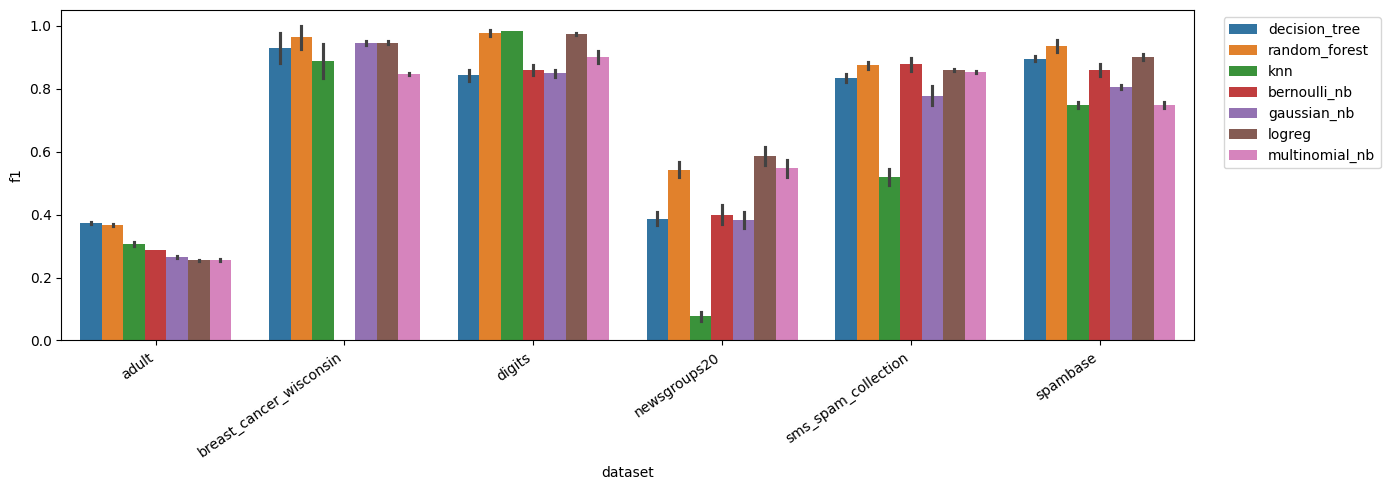

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = benchmark_df.sort_values(['dataset', 'split', 'f1'], ascending=[True, True, False])

plt.figure(figsize=(14, 5))
sns.barplot(data=plot_df, x='dataset', y='f1', hue='model', dodge=True)
plt.xticks(rotation=35, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)           # не сворачивать строку
pd.set_option('display.max_colwidth', None)    # длинные ячейки не обрезать

df = benchmark_df.sort_values(['dataset', 'split', 'f1'], ascending=[True, True, False]).round(4)
display(df)
ёёё

,dataset,model,split,accuracy,precision,recall,f1,roc_auc,log_loss
37,adult,decision_tree,test,0.4563,0.3778,0.3779,0.3778,0.5854,19.5880
41,adult,random_forest,test,0.5291,0.3888,0.3870,0.3705,0.7373,1.0912
39,adult,knn,test,0.4720,0.3411,0.3049,0.3008,0.5829,6.7499
35,adult,bernoulli_nb,test,0.5034,0.2504,0.3786,0.2866,0.7245,1.3140
31,adult,gaussian_nb,test,0.5229,0.3130,0.3107,0.2621,0.6839,1.6739
29,adult,logreg,test,0.5247,0.2462,0.3052,0.2538,0.5618,1.1670
33,adult,multinomial_nb,test,0.4928,0.2993,0.2960,0.2512,0.5591,11.2897
36,adult,decision_tree,val,0.4440,0.3706,0.3707,0.3706,0.5789,20.0403
40,adult,random_forest,val,0.5170,0.3809,0.3784,0.3641,0.7289,1.1258
38,adult,knn,val,0.4796,0.3587,0.3135,0.3124,0.5832,6.6339


,dataset,model,split,accuracy,precision,recall,f1,roc_auc,log_loss
37,adult,decision_tree,test,0.4563,0.3778,0.3779,0.3778,0.5854,19.5880
41,adult,random_forest,test,0.5291,0.3888,0.3870,0.3705,0.7373,1.0912
39,adult,knn,test,0.4720,0.3411,0.3049,0.3008,0.5829,6.7499
35,adult,bernoulli_nb,test,0.5034,0.2504,0.3786,0.2866,0.7245,1.3140
31,adult,gaussian_nb,test,0.5229,0.3130,0.3107,0.2621,0.6839,1.6739
29,adult,logreg,test,0.5247,0.2462,0.3052,0.2538,0.5618,1.1670
33,adult,multinomial_nb,test,0.4928,0.2993,0.2960,0.2512,0.5591,11.2897
36,adult,decision_tree,val,0.4440,0.3706,0.3707,0.3706,0.5789,20.0403
40,adult,random_forest,val,0.5170,0.3809,0.3784,0.3641,0.7289,1.1258
38,adult,knn,val,0.4796,0.3587,0.3135,0.3124,0.5832,6.6339
